# Pruebas de la interfaz y del motor de vigilancia

Este notebook ejecuta escenarios controlados sobre la logica que sostiene la app de Streamlit. La idea es comprobar que el sistema responde bien cuando se guardan revisiones, cambian las metricas, se generan alertas y se actualiza la auditoria.

Cada escenario crea su propio entorno de prueba, con CSV temporales independientes del estado real de la app. De esta forma podemos forzar situaciones concretas y verificar que el backend responde como esperamos.

Las pruebas se ejecutan en un entorno aislado dentro de `code/outputs/pruebas_interfaz`, por lo que no se modifica el estado real de la aplicacion.

## 1) Preparacion

En esta primera parte cargamos el backend real, el registro de inferencias generado por el notebook del modelo y definimos funciones auxiliares para lanzar escenarios sin tocar los CSV habituales de la aplicacion.

La idea es sencilla. Primero guardamos las rutas originales del sistema. Luego, para cada escenario, redireccionamos el backend a una carpeta temporal de pruebas. Asi conseguimos que cada caso se pueda repetir las veces que haga falta y que los resultados dependan solo del escenario diseñado.

In [23]:
# Importaciones basicas para manejar rutas, tablas y graficas.
import sys
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
import vigilance_backend as core

# Ruta base donde se aloja el codigo
RUTA_CODE = "/Users/emiliopesenti/Desktop/Practicas&TFG/TFG/SistemaAlerta/code"

# Carpeta donde se guardaran todos los escenarios de prueba
RUTA_PRUEBAS = Path(RUTA_CODE) / "outputs" / "pruebas_interfaz"
RUTA_PRUEBAS.mkdir(parents=True, exist_ok=True)

# Guardamos las rutas reales del backend para poder restaurarlas al final
RUTAS_ORIGINALES = {
    "ARCHIVO_REGISTRO_INFERENCIAS": core.ARCHIVO_REGISTRO_INFERENCIAS,
    "ARCHIVO_REGISTRO_INFERENCIAS_ANTIGUO": core.ARCHIVO_REGISTRO_INFERENCIAS_ANTIGUO,
    "ARCHIVO_FEEDBACK": core.ARCHIVO_FEEDBACK,
    "ARCHIVO_ALERTAS": core.ARCHIVO_ALERTAS,
    "ARCHIVO_ESTADO_ALERTAS": core.ARCHIVO_ESTADO_ALERTAS,
    "ARCHIVO_AUDITORIA": core.ARCHIVO_AUDITORIA,
}

# Este es el registro real generado por el notebook del modelo
# A partir de aqui elegimos subconjuntos de casos para construir cada escenario
ruta_registro_real = Path(RUTA_CODE) / "outputs" / "tablas" / "registro_inferencias_modelo.csv"
registro_real = pd.read_csv(ruta_registro_real)

print("Registro de inferencias disponible:", len(registro_real), "casos")
display(registro_real[["id_estudio", "parte_anatomica", "etiqueta_predicha", "probabilidad_anormalidad"]].head(5))

Registro de inferencias disponible: 1199 casos


,id_estudio,parte_anatomica,etiqueta_predicha,probabilidad_anormalidad
0,XR_ELBOW_patient11186_study1_positive,XR_ELBOW,1,0.999966
1,XR_ELBOW_patient11189_study1_positive,XR_ELBOW,1,0.999013
2,XR_ELBOW_patient11204_study1_negative,XR_ELBOW,0,0.057030
3,XR_ELBOW_patient11205_study1_negative,XR_ELBOW,0,0.005205
4,XR_ELBOW_patient11217_study1_negative,XR_ELBOW,1,0.988362


In [35]:
def seleccionar_casos(condicion, n):
    """Filtra casos del registro real y devuelve los n primeros que cumplen la condicion."""
    # registro_real[condicion] filtra los casos que cumplen la condicion, head(n) toma los primeros n, reset_index(drop=True) reinicia el indice y copy() crea una copia del DataFrame resultante.
    return registro_real[condicion].head(n).reset_index(drop=True).copy() 

def preparar_csv_vacio(path, columnas):
    """Crea un DataFrame vacio con las columnas esperadas por el backend y lo guarda como un CSV."""
    pd.DataFrame(columns=columnas).to_csv(path, index=False)


def activar_escenario(nombre, registro_escenario=None):
    """Crea una carpeta aislada de prueba y conecta el backend a ese escenario."""
    # Cada escenario de prueba vive en su propia carpeta para que sus archivos no interfieran con otros escenarios ni con los CSV reales de la app.

    # Creamos carpeta de escenario (si ya existía se borra y se vuelve a crear)
    carpeta = RUTA_PRUEBAS / nombre
    if carpeta.exists():
        shutil.rmtree(carpeta)
    carpeta.mkdir(parents=True)

    # Definimos los 5 archivos que va a usar ese escenario
    rutas = {
        "registro": carpeta / "registro_inferencias_modelo.csv",
        "feedback": carpeta / "feedback_manual.csv",
        "alertas": carpeta / "alertas_generadas.csv",
        "estado_alertas": carpeta / "alertas_estado.csv",
        "auditoria": carpeta / "audit_log.csv",
    }

    # Si se pasa un registro reducido, el escenario trabaja con ese subconjunto.
    # Si no se pasa nada, se mantiene el registro real completo.
    if registro_escenario is None:
        rutas["registro"] = ruta_registro_real
    else:
        registro_escenario.to_csv(rutas["registro"], index=False)

    preparar_csv_vacio(rutas["feedback"], core.COLUMNAS_FEEDBACK)
    preparar_csv_vacio(rutas["alertas"], core.COLUMNAS_ALERTAS)
    preparar_csv_vacio(rutas["estado_alertas"], core.COLUMNAS_ESTADO)
    preparar_csv_vacio(rutas["auditoria"], core.COLUMNAS_AUDITORIA)

    # Aqui redirigimos el backend real para que mientras dure la prueba, lea y escriba solo sobre los archivos de este escenario.
    core.ARCHIVO_REGISTRO_INFERENCIAS = rutas["registro"]
    core.ARCHIVO_REGISTRO_INFERENCIAS_ANTIGUO = rutas["registro"]
    core.ARCHIVO_FEEDBACK = rutas["feedback"]
    core.ARCHIVO_ALERTAS = rutas["alertas"]
    core.ARCHIVO_ESTADO_ALERTAS = rutas["estado_alertas"]
    core.ARCHIVO_AUDITORIA = rutas["auditoria"]

    return carpeta, rutas


def registrar_revision_completa(caso, etiqueta_ap, incidencia="none", nota=""):
    """Simula lo que haría la app cuando un médico revisa un caso"""
    # Antes de guardar una nueva revision, leemos las alertas previas para poder
    # comparar despues que alertas existian ya y cuales aparecen como nuevas.
    alertas_anteriores = core.cargar_alertas_previas()
    feedback = core.guardar_feedback(caso, etiqueta_ap, incidencia, nota)

    # Una vez guardado el feedback, reconstruimos el registro con esa revision aplicada
    # y nos quedamos solo con los casos que ya tienen valoracion humana.
    registro_actualizado = core.aplicar_feedback(core.cargar_registro_inferencias(), core.cargar_feedback())
    revisados = registro_actualizado[registro_actualizado["tiene_feedback_manual"]].copy()

    # A partir de los casos revisados recalculamos alertas, detectamos las nuevas
    # y registramos en auditoria tanto la decision humana como las alertas generadas.
    alertas_actuales = core.construir_alertas(revisados)
    alertas_nuevas = core.alertas_nuevas(alertas_anteriores, alertas_actuales)
    core.guardar_alertas_previas(alertas_actuales)

    eventos = [core.evento_decision(caso, feedback, alertas_nuevas), *core.eventos_alertas(alertas_nuevas)]
    core.guardar_eventos_auditoria(eventos)
    return feedback, alertas_nuevas


def comprobar(comprobaciones, nombre, condicion, detalle=""):
    """Añade una comprobacion booleana al resumen final del escenario."""
    # Guardamos cada comprobacion con su nombre, si pasa o no, y un detalle corto
    # para que luego sea facil justificar el resultado del escenario.
    comprobaciones.append({
        "comprobacion": nombre,
        "ok": bool(condicion), # ok: True o ok: False
        "detalle": detalle,
    })


def mostrar_comprobaciones(comprobaciones):
    """Convierte los cheks en tabla, la muestra y la devuelve"""
    # Esta tabla resume visualmente el resultado del escenario.
    tabla = pd.DataFrame(comprobaciones)
    display(tabla)


def buscar_caso(registro, id_estudio):
    """Busca un caso concreto dentro del registro activo del escenario."""
    # Buscamos caso concreto por id, forzamos comparación como texto y devolvemos la primera coincidencia.
    return registro[registro["id_estudio"].astype(str) == str(id_estudio)].iloc[0]


def registrar_revisiones_ids(registro, ids_casos, etiqueta_ap, incidencia="none", nota=""):
    """Aplica la misma logica de revision a varios casos identificados por su id."""
    # Sirve para automatizar escenarios repetitivos donde varios casos siguen
    # el mismo patron de revision humana.
    for id_caso in ids_casos:
        caso = buscar_caso(registro, id_caso)
        # Si etiqueta_ap es una funcion, la aplicamos al caso, si es un valor fijo, lo usamos tal cual
        etiqueta = etiqueta_ap(caso) if callable(etiqueta_ap) else etiqueta_ap
        registrar_revision_completa(caso, int(etiqueta), incidencia, nota)


def reconstruir_escenario_alertas_globales(nombre, registro_escenario, ids_fn, id_tn, ids_fp, id_tp):
    """Reconstruye el escenario base de alertas globales para reutilizarlo en varias pruebas."""
    # Vuelve a montar siempre el mismo patron base de casos correctos e
    # incorrectos para no duplicar codigo en escenarios de alertas globales.
    activar_escenario(nombre, registro_escenario)
    registro, _, _, _, _ = core.cargar_estado()
    registrar_revisiones_ids(registro, ids_fn, 1, "none", "FN alta confianza")
    registrar_revisiones_ids(registro, [id_tn], 0, "none", "Acierto normal")
    registrar_revisiones_ids(registro, ids_fp, 0, "none", "FP alta confianza")
    registrar_revisiones_ids(registro, [id_tp], 1, "none", "Acierto anormal")
    return core.cargar_estado()


def cerrar_alerta_y_registrar(alerta, nuevo_estado="closed", motivo="Cierre de prueba", detalle="Se documenta una revision controlada del escenario", accion="no"):
    """Cierra una alerta y registra su cambio de estado en auditoria."""
    # En la app, cambiar el estado de una alerta no solo modifica su situacion actual,
    # tambien deja rastro en auditoria. Aqui reproducimos ambas cosas.
    core.cambiar_estado_alerta(alerta["id_alerta"], nuevo_estado, motivo, detalle, "responsable_vigilancia", accion)
    core.guardar_eventos_auditoria([
        core.evento_estado_alerta(alerta, nuevo_estado, motivo, detalle, accion)
    ])


def dibujar_barras_suaves(serie, etiqueta_y, colores=None, rotacion=18):
    """Dibuja una grafica de barras simple y uniforme para documentar escenarios."""
    # Esta funcion solo tiene objetivo de mostrar de forma clara y homogénea
    # el resultado numerico de algunas pruebas dentro del notebook.
    valores = serie.astype(float)
    paleta = colores or ["#8fbcd4"] * len(valores)

    fig, ax = plt.subplots(figsize=(8, 4.8))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("#f8fafc")

    barras = ax.bar(
        valores.index,
        valores.values,
        color=paleta,
        edgecolor="#adc4d4",
        linewidth=0.8,
        alpha=0.95,
    )

    ax.set_ylim(0, 1.05)
    ax.set_ylabel(etiqueta_y)
    ax.grid(axis="y", linestyle="--", alpha=0.25, color="#94a3b8")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cbd5e1")
    ax.spines["bottom"].set_color("#cbd5e1")
    ax.tick_params(axis="x", rotation=rotacion)

    # Ajustamos la alineacion de las etiquetas del eje X para que se lean bien
    # aunque los nombres sean algo largos.
    for etiqueta in ax.get_xticklabels():
        etiqueta.set_ha("right" if rotacion else "center")

    # Escribimos el valor exacto encima de cada barra para que la grafica
    # pueda leerse sin depender solo de la escala.
    for barra in barras:
        altura = barra.get_height()
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.02,
            f"{altura:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            color="#475569",
        )

    plt.tight_layout()
    plt.show()

## 2) Escenario 1. Carga inicial de inferencias sin feedback

Este escenario comprueba el comportamiento minimo del sistema cuando existe un registro de inferencias, pero todavia no se ha guardado ninguna revision humana.

Aqui esperamos un estado completamente limpio. Deben cargarse los casos, pero no debe haber feedback, ni alertas, ni eventos de auditoria. Esta prueba sirve como punto de partida para el resto, porque valida que el backend no genera informacion de vigilancia antes de que exista interaccion humana.

In [ ]:
# Elegimos 8 casos del registro real, mezclando normales y anormales con alta confianza
# No importa todavia si son correctos o incorrectos, solo queremos un conjunto de entrada valido

# Escogemos 4 anormales y 4 normales muy seguros (alta confianza)
casos_normales = seleccionar_casos(
    (registro_real["etiqueta_predicha"] == 0) & (registro_real["probabilidad_anormalidad"] <= 0.20), 4,)
casos_anormales = seleccionar_casos(
    (registro_real["etiqueta_predicha"] == 1) & (registro_real["probabilidad_anormalidad"] >= 0.80), 4,)

# Juntamos ambos grupos en un mini registro
registro_escenario_1 = pd.concat([casos_normales, casos_anormales], ignore_index=True)

# Activamos un escenario aislado con esos 8 casos y cargamos el estado resultante con la funcion del backend
activar_escenario("escenario_01_sin_feedback", registro_escenario_1)
registro, feedback, revisados, alertas, auditoria = core.cargar_estado() 

# Comprobamos que el sistema arranca limpio: solo hay registro, pero no actividad de vigilancia aun
comprobaciones = []
comprobar(comprobaciones, "Se cargan los 8 casos del escenario", len(registro) == 8, f"n={len(registro)}")    # Verificamos que hay 8 casos
comprobar(comprobaciones, "No hay feedback guardado", feedback.empty, f"filas feedback={len(feedback)}")      # Que no hay feedback previo
comprobar(comprobaciones, "No hay casos revisados", revisados.empty, f"revisados={len(revisados)}")           # Que no hay casos revisados aun
comprobar(comprobaciones, "No se generan alertas antes de revisar", alertas.empty, f"alertas={len(alertas)}") # Que no hay alertas aun
comprobar(comprobaciones, "La auditoria arranca vacia", auditoria.empty, f"eventos={len(auditoria)}")         # Que no hay auditoria aun

print("Vista del registro cargado para el escenario 1")
display(registro[["id_estudio", "parte_anatomica", "etiqueta_predicha", "probabilidad_anormalidad"]])
mostrar_comprobaciones(comprobaciones)

Vista del registro cargado para el escenario 1


,id_estudio,parte_anatomica,etiqueta_predicha,probabilidad_anormalidad
0,XR_ELBOW_patient11186_study1_positive,XR_ELBOW,1,0.999966
1,XR_ELBOW_patient11189_study1_positive,XR_ELBOW,1,0.999013
2,XR_ELBOW_patient11204_study1_negative,XR_ELBOW,0,0.057030
3,XR_ELBOW_patient11205_study1_negative,XR_ELBOW,0,0.005205
4,XR_ELBOW_patient11217_study1_negative,XR_ELBOW,1,0.988362
5,XR_ELBOW_patient11222_study1_negative,XR_ELBOW,0,0.073455
6,XR_ELBOW_patient11235_study1_negative,XR_ELBOW,0,0.067463
7,XR_ELBOW_patient11236_study1_positive,XR_ELBOW,1,0.999806


,comprobacion,ok,detalle
0,Se cargan los 8 casos del escenario,True,n=8
1,No hay feedback guardado,True,filas feedback=0
2,No hay casos revisados,True,revisados=0
3,No se generan alertas antes de revisar,True,alertas=0
4,La auditoria arranca vacia,True,eventos=0


## 3) Escenario 2. Flujo basico de revision clinica

Aqui comprobamos que guardar valoraciones humanas actualiza el numero de revisados, las metricas basicas y la auditoria, incluso cuando hay incidencias de revision.

En otras palabras, en esta prueba se revisan varios casos, se fuerzan decisiones distintas y luego se comprueba que el backend integra esa informacion correctamente. Como todavia hay pocas revisiones, en este escenario aun no deberian saltar alertas.

In [26]:
# Construimos un escenario pequeno con 6 casos para simular las primeras revisiones humanas
registro_escenario_2 = pd.concat([casos_normales.iloc[:3], casos_anormales.iloc[:3]], ignore_index=True)

# Guardamos 3 ids concretos para simular tres tipos de revisión
id_acuerdo_1 = registro_escenario_2.iloc[0]["id_estudio"]
id_desacuerdo = registro_escenario_2.iloc[1]["id_estudio"]
id_acuerdo_2 = registro_escenario_2.iloc[4]["id_estudio"]

activar_escenario("escenario_02_revision_basica", registro_escenario_2)
registro, _, _, _, _ = core.cargar_estado()

# Simulamos tres tipos de revision: 
    # 1) Médico de acuerdo con el modelo
    # 2) Médico en desacuerdo con el modelo
    # 3) Médico de acuerdo con el modelo pero detectando una incidencia tecnica
registrar_revisiones_ids(registro, [id_acuerdo_1], lambda caso: caso["etiqueta_predicha"], "none", "Revision con acuerdo")
registrar_revisiones_ids(registro, [id_desacuerdo], lambda caso: 1 - int(caso["etiqueta_predicha"]), "doubtful", "Se fuerza una discrepancia para probar el flujo")
registrar_revisiones_ids(registro, [id_acuerdo_2], lambda caso: caso["etiqueta_predicha"], "poor_image_quality", "Caso con incidencia tecnica")

# Recargamos el estado depués de las revisiones y calculamos las metricas con las funciones del backend
registro_2, feedback_2, revisados_2, alertas_2, auditoria_2 = core.cargar_estado()
metricas_2 = core.calcular_metricas(revisados_2)

# Comprobamos
comprobaciones = []
comprobar(comprobaciones, "Quedan 3 revisiones guardadas", len(revisados_2) == 3, f"revisados={len(revisados_2)}")
comprobar(comprobaciones, "La auditoria registra 3 decisiones clinicas", (auditoria_2["tipo_evento"] == "decision_clinica").sum() == 3, f"eventos={len(auditoria_2)}")
comprobar(comprobaciones, "La metrica n coincide con los revisados", metricas_2["n"] == 3, f"n metricas={metricas_2['n']}")
comprobar(comprobaciones, "El desacuerdo ya no es cero", metricas_2["desacuerdo"] > 0, f"desacuerdo={metricas_2['desacuerdo']}")
comprobar(comprobaciones, "Aun no se generan alertas con menos de 5 revisiones", alertas_2.empty, f"alertas={len(alertas_2)}")

print("Revisiones guardadas en el escenario 2")
display(revisados_2[[
    "id_estudio", "etiqueta_predicha", "etiqueta_final",
    "estado_acuerdo_efectivo", "incidencia_revision_efectiva"
]])

print("Eventos de auditoria")
display(auditoria_2[["tipo_evento", "id_caso", "decision_humana", "alerta_generada", "actor", "notas"]])
mostrar_comprobaciones(comprobaciones)

Revisiones guardadas en el escenario 2


,id_estudio,etiqueta_predicha,etiqueta_final,estado_acuerdo_efectivo,incidencia_revision_efectiva
1,XR_ELBOW_patient11189_study1_positive,1,1.0,agree,poor_image_quality
2,XR_ELBOW_patient11204_study1_negative,0,0.0,agree,none
3,XR_ELBOW_patient11205_study1_negative,0,1.0,disagree,doubtful


Eventos de auditoria


,tipo_evento,id_caso,decision_humana,alerta_generada,actor,notas
0,decision_clinica,XR_ELBOW_patient11204_study1_negative,agree,NaN,medico_urgencias,Incidencia revision: Sin incidencia | Revision...
1,decision_clinica,XR_ELBOW_patient11205_study1_negative,disagree,NaN,medico_urgencias,Incidencia revision: Caso dudoso | Se fuerza u...
2,decision_clinica,XR_ELBOW_patient11189_study1_positive,agree,NaN,medico_urgencias,Incidencia revision: Mala calidad de imagen | ...


,comprobacion,ok,detalle
0,Quedan 3 revisiones guardadas,True,revisados=3
1,La auditoria registra 3 decisiones clinicas,True,eventos=3
2,La metrica n coincide con los revisados,True,n metricas=3
3,El desacuerdo ya no es cero,True,desacuerdo=0.3333333333333333
4,Aun no se generan alertas con menos de 5 revis...,True,alertas=0


## 4) Escenario 3. Alertas globales y tablas de vigilancia

Este escenario fuerza errores claros del modelo para comprobar que se activan las alertas globales, que la matriz de confusion se construye bien y que la tabla de calibracion refleja los errores de alta confianza.

Aqui ya entramos en la parte mas interesante de la vigilancia. La idea es provocar un patron de fallo muy visible, con falsos negativos y falsos positivos de alta confianza, para comprobar que el sistema traduce esas señales en metricas, tablas y alertas coherentes.

Metricas del escenario 3


,n,tp,tn,fp,fn,recall,fnr,accuracy,desacuerdo,error_alta_conf,fn_alta_conf,error_alta_conf_rate
0,6,1,1,2,2,0.333333,0.666667,0.333333,0.666667,4,2,0.666667


Alertas generadas


,codigo_alerta,severidad,indicador,valor_observado,umbral,accion_recomendada,destinatario
4,CAL-01,red,high_confidence_error_count,4.0000,1.00,Auditar calibracion del modelo y revisar error...,responsable_vigilancia
0,CLIN-01,red,recall,0.3333,0.70,Revisar positivos omitidos y subgrupos afectados,responsable_vigilancia
1,CLIN-02,red,false_negative_rate,0.6667,0.30,Listar falsos negativos y revisar calidad/part...,responsable_vigilancia
3,CLIN-03,red,high_confidence_false_negative_count,2.0000,1.00,Revision prioritaria de casos con probabilidad...,especialista_radiologia
5,CLIN-04,red,localized_false_negative_rate,0.6667,0.18,Revisar rendimiento localizado en XR_ELBOW; co...,responsable_vigilancia
2,USE-01,red,clinical_disagreement_rate,0.6667,0.30,Revisar feedback clinico y presentacion de res...,responsable_vigilancia


Matriz de confusion


,referencia,prediccion,casos
0,normal,normal,1
1,normal,anormal,2
2,anormal,normal,2
3,anormal,anormal,1


Tabla de calibracion


,rango_probabilidad,casos,anormal_real,pred_anormal,error,error_alta_conf
0,0.0-0.2,3,0.666667,0.0,0.666667,2
1,0.8-1.0,3,0.333333,1.0,0.666667,2


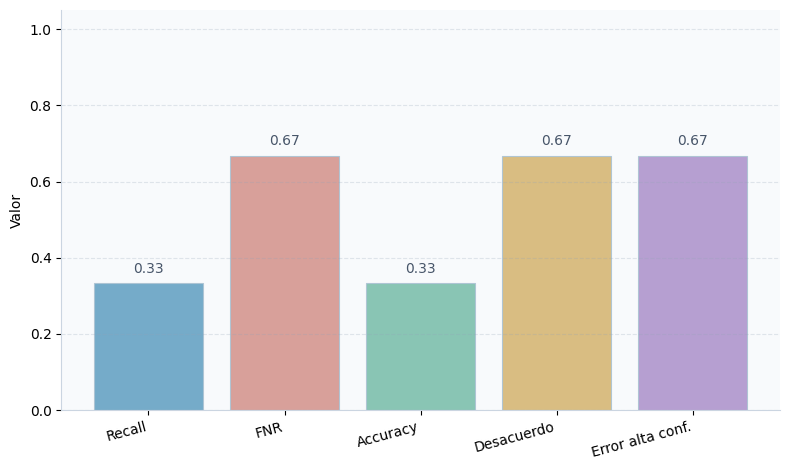

,comprobacion,ok,detalle
0,Se revisan los 6 casos del escenario,True,revisados=6
1,Salta CLIN-01 por recall bajo,True,"['CAL-01', 'CLIN-01', 'CLIN-02', 'CLIN-03', 'C..."
2,Salta CLIN-02 por FNR elevado,True,"['CAL-01', 'CLIN-01', 'CLIN-02', 'CLIN-03', 'C..."
3,Salta USE-01 por desacuerdo alto,True,"['CAL-01', 'CLIN-01', 'CLIN-02', 'CLIN-03', 'C..."
4,Salta CLIN-03 por falsos negativos de alta con...,True,"['CAL-01', 'CLIN-01', 'CLIN-02', 'CLIN-03', 'C..."
5,Salta CAL-01 por errores de alta confianza,True,"['CAL-01', 'CLIN-01', 'CLIN-02', 'CLIN-03', 'C..."
6,La matriz de confusion tiene 4 celdas,True,celdas=4
7,La tabla de calibracion no esta vacia,True,filas=2


In [36]:
# Seleccionamos casos normales con probabilidad muy baja y anormales con probabilida muy alta para poder forzar errores graves
negativas_alta_conf = seleccionar_casos(
    (registro_real["etiqueta_predicha"] == 0) & (registro_real["probabilidad_anormalidad"] <= 0.20), 3,)
positivas_alta_conf = seleccionar_casos(
    (registro_real["etiqueta_predicha"] == 1) & (registro_real["probabilidad_anormalidad"] >= 0.80), 3,)
registro_escenario_3 = pd.concat([negativas_alta_conf, positivas_alta_conf], ignore_index=True)

# Diseñamos el patron del escenario 
ids_fn = registro_escenario_3.iloc[0:2]["id_estudio"].tolist()  # dos falsos negativos
id_tn = registro_escenario_3.iloc[2]["id_estudio"]              # un verdadero negativo
ids_fp = registro_escenario_3.iloc[3:5]["id_estudio"].tolist()  # dos falsos positivos
id_tp = registro_escenario_3.iloc[5]["id_estudio"]              # un verdadero positivo

# Montamos el escenario
registro_3, feedback_3, revisados_3, alertas_3, auditoria_3 = reconstruir_escenario_alertas_globales(
    "escenario_03_alertas_globales", registro_escenario_3, ids_fn, id_tn, ids_fp, id_tp)

# Calculamos las metricas, la matriz de confusion y construimos la tabla de calibracion con las funciones del backend
metricas_3 = core.calcular_metricas(revisados_3)
matriz_3 = core.matriz_confusion(revisados_3)
calibracion_3 = core.tabla_calibracion(revisados_3)

# Sacamos los codigos de alerta generados para poder comprobarlos facilmente
codigos_alerta_3 = set(alertas_3["codigo_alerta"].tolist())

# Verificamos que el patron de fallo dispara las alertas esperadas.
comprobaciones = []
comprobar(comprobaciones, "Se revisan los 6 casos del escenario", len(revisados_3) == 6, f"revisados={len(revisados_3)}")
comprobar(comprobaciones, "Salta CLIN-01 por recall bajo", "CLIN-01" in codigos_alerta_3, str(sorted(codigos_alerta_3)))
comprobar(comprobaciones, "Salta CLIN-02 por FNR elevado", "CLIN-02" in codigos_alerta_3, str(sorted(codigos_alerta_3)))
comprobar(comprobaciones, "Salta USE-01 por desacuerdo alto", "USE-01" in codigos_alerta_3, str(sorted(codigos_alerta_3)))
comprobar(comprobaciones, "Salta CLIN-03 por falsos negativos de alta confianza", "CLIN-03" in codigos_alerta_3, str(sorted(codigos_alerta_3)))
comprobar(comprobaciones, "Salta CAL-01 por errores de alta confianza", "CAL-01" in codigos_alerta_3, str(sorted(codigos_alerta_3)))
comprobar(comprobaciones, "La matriz de confusion tiene 4 celdas", len(matriz_3) == 4, f"celdas={len(matriz_3)}")
comprobar(comprobaciones, "La tabla de calibracion no esta vacia", not calibracion_3.empty, f"filas={len(calibracion_3)}")

print("Metricas del escenario 3")
display(pd.DataFrame([metricas_3])[[
    "n", "tp", "tn", "fp", "fn", "recall", "fnr", "accuracy",
    "desacuerdo", "error_alta_conf", "fn_alta_conf", "error_alta_conf_rate"]])

print("Alertas generadas")
display(alertas_3[[
    "codigo_alerta", "severidad", "indicador", "valor_observado",
    "umbral", "accion_recomendada", "destinatario"]].sort_values(["severidad", "codigo_alerta"]))

print("Matriz de confusion")
display(matriz_3)

print("Tabla de calibracion")
display(calibracion_3)

# Representacion visual resumida para documentar el escenario en la memoria.
grafica_metricas_3 = pd.Series({
    "Recall": metricas_3["recall"],
    "FNR": metricas_3["fnr"],
    "Accuracy": metricas_3["accuracy"],
    "Desacuerdo": metricas_3["desacuerdo"],
    "Error alta conf.": metricas_3["error_alta_conf_rate"],
})
dibujar_barras_suaves(
    grafica_metricas_3,
    "Valor",
    colores=["#6ea7c7", "#d79b95", "#83c3b0", "#d8ba7b", "#b39acf"],
    rotacion=15,
)

mostrar_comprobaciones(comprobaciones)

## 5) Escenario 4. Degradacion localizada por parte anatomica

En esta prueba concentramos errores dentro de una sola region anatomica para comprobar que el sistema detecta una degradacion localizada y genera la alerta correspondiente.

La importancia de este escenario es que demuestra que un sistema puede parecer aceptable en promedio y, aun asi, fallar de manera concentrada en una parte concreta del cuerpo. Aqui comprobamos precisamente esa capacidad de vigilancia localizada.

In [ ]:
# Buscamos casos de codo que el modelo predice como normales con mucha confianza.
# Sobre ellos vamos a forzar varios falsos negativos concentrados en la misma region anatomica.

codos_normales_alta_conf = seleccionar_casos(
    (registro_real["parte_anatomica"] == "XR_ELBOW") & 
    (registro_real["etiqueta_predicha"] == 0) & 
    (registro_real["probabilidad_anormalidad"] <= 0.20), 5,)

registro_escenario_4 = codos_normales_alta_conf.copy().reset_index(drop=True)
ids_fn_local = registro_escenario_4.iloc[0:2]["id_estudio"].tolist()  # separamos dos casos para forzar falsos negativos localizados
ids_tn_local = registro_escenario_4.iloc[2:5]["id_estudio"].tolist()  # separamos tres casos para forzar verdaderos negativos localizados

# Activamos el escenario
activar_escenario("escenario_04_degradacion_localizada", registro_escenario_4)
registro, _, _, _, _ = core.cargar_estado()

# Forzamos el patron localizado: dos FN en codo y tres casos correctamente aceptados como normales.
for id_caso in ids_fn_local:
    registrar_revision_completa(buscar_caso(registro, id_caso), 1, "none", "FN localizado")
for id_caso in ids_tn_local:
    registrar_revision_completa(buscar_caso(registro, id_caso), 0, "none", "Normal aceptado")

# Recargamos el estado depués de las revisiones y calculamos las metricas con las funciones del backend
registro_4, feedback_4, revisados_4, alertas_4, auditoria_4 = core.cargar_estado()
por_parte_4 = core.metricas_por_parte_anatomica(revisados_4)

# Buscamos las alertas CLIN-04 que se generan por falsos negativos localizados en la misma parte anatomica.
alertas_localizadas_4 = alertas_4[alertas_4["codigo_alerta"] == "CLIN-04"].copy()

# Comprobamos
comprobaciones = []
comprobar(comprobaciones, "Se genera al menos una alerta CLIN-04", not alertas_localizadas_4.empty, f"alertas CLIN-04={len(alertas_localizadas_4)}")
comprobar(comprobaciones, "La alerta localizada afecta a XR_ELBOW", (alertas_localizadas_4["alcance"] == "XR_ELBOW").any(), str(alertas_localizadas_4.get("alcance", [])))
comprobar(comprobaciones, "Las metricas por parte no estan vacias", not por_parte_4.empty, f"filas={len(por_parte_4)}")

print("Metricas por parte anatomica")
display(por_parte_4)

print("Alertas localizadas")
display(alertas_localizadas_4[[
    "codigo_alerta", "nombre_alerta", "severidad", "alcance",
    "valor_observado", "tamano_muestra", "evidencias"
]])
mostrar_comprobaciones(comprobaciones)


Metricas por parte anatomica


,parte_anatomica,n,tp,tn,fp,fn,recall,fnr,f1,accuracy,...,drift_prediccion,drift_global,n_normal,acierto_normal,desacuerdo_normal,error_alta_conf_rate_normal,n_anormal,acierto_anormal,desacuerdo_anormal,error_alta_conf_rate_anormal
0,XR_ELBOW,5,0,3,0,2,0.0,1.0,NaN,0.6,...,0.0,0.0,3,1.0,0.0,0.0,2,0.0,1.0,1.0


Alertas localizadas


,codigo_alerta,nombre_alerta,severidad,alcance,valor_observado,tamano_muestra,evidencias
5,CLIN-04,Patron emergente: degradacion localizada en XR...,red,XR_ELBOW,1.0,5,XR_ELBOW_patient11204_study1_negative;XR_ELBOW...


,comprobacion,ok,detalle
0,Se genera al menos una alerta CLIN-04,True,alertas CLIN-04=1
1,La alerta localizada afecta a XR_ELBOW,True,"5 XR_ELBOW\nName: alcance, dtype: str"
2,Las metricas por parte no estan vacias,True,filas=1


## 6) Escenario 5. Cambio de estado de alerta y auditoria

El objetivo ahora es comprobar que cerrar una alerta modifica su estado efectivo y deja un evento nuevo en auditoria sin borrar el evento original de generacion.

En un sistema de vigilancia, lo relevante no es solo que una alerta aparezca, sino que pueda seguirse su ciclo de vida completo y quede constancia de quien la cerro, cuando y por que.

In [ ]:
# Reutilizamos el escenario 3 porque ya sabemos que genera varias alertas globales
registro_5, feedback_5, revisados_5, alertas_5, auditoria_5 = reconstruir_escenario_alertas_globales(
    "escenario_05_cierre_alerta", registro_escenario_3, ids_fn, id_tn, ids_fp, id_tp
)

# Elegimos una alerta real del escenario y la cerramos manualmente.
alerta_cerrar = alertas_5[alertas_5["codigo_alerta"] == "CLIN-03"].iloc[0].to_dict()
cerrar_alerta_y_registrar(alerta_cerrar)

# Recargamos el estado de la alertas y recargamos la auditoria para comprobar que el cierre se ha registrado correctamente
alertas_con_estado_5 = core.combinar_estado_alertas(alertas_5)
auditoria_5 = core.cargar_auditoria()

# Comprobamos
comprobaciones = []
comprobar(
    comprobaciones,
    "La alerta CLIN-03 aparece como cerrada tras actualizar su estado",
    (alertas_con_estado_5.loc[alertas_con_estado_5["id_alerta"] == alerta_cerrar["id_alerta"], "estado_efectivo"] == "closed").any(),
    alerta_cerrar["id_alerta"],)
comprobar(
    comprobaciones,
    "La auditoria contiene un evento de cambio de estado",
    ((auditoria_5["tipo_evento"] == "estado_alerta") & (auditoria_5["id_alerta"] == alerta_cerrar["id_alerta"])).any(),
    alerta_cerrar["id_alerta"],)

print("Estado efectivo de las alertas")
display(alertas_con_estado_5[["codigo_alerta", "severidad", "estado_efectivo", "id_alerta"]])

print("Eventos de auditoria asociados a la alerta cerrada")
display(auditoria_5[auditoria_5["id_alerta"] == alerta_cerrar["id_alerta"]][[
    "fecha", "tipo_evento", "alerta_generada", "estado_alerta", "motivo_cierre", "accion_realizada"
]])
mostrar_comprobaciones(comprobaciones)

Estado efectivo de las alertas


,codigo_alerta,severidad,estado_efectivo,id_alerta
0,CLIN-01,red,open,alerta_clin-01_global_red_a762fe86
1,CLIN-02,red,open,alerta_clin-02_global_red_a762fe86
2,USE-01,red,open,alerta_use-01_global_red_a762fe86
3,CLIN-03,red,closed,alerta_clin-03_global_red_a762fe86
4,CAL-01,red,open,alerta_cal-01_global_red_a762fe86
5,CLIN-04,red,open,alerta_clin-04_xr_elbow_red_a762fe86


Eventos de auditoria asociados a la alerta cerrada


,fecha,tipo_evento,alerta_generada,estado_alerta,motivo_cierre,accion_realizada
8,2026-06-18T20:36:08Z,alerta_generada,CLIN-03:red,open,NaN,NaN
12,2026-06-18T20:36:08Z,estado_alerta,CLIN-03:red,closed,Cierre de prueba,Se documenta una revision controlada del escen...


,comprobacion,ok,detalle
0,La alerta CLIN-03 aparece como cerrada tras ac...,True,alerta_clin-03_global_red_a762fe86
1,La auditoria contiene un evento de cambio de e...,True,alerta_clin-03_global_red_a762fe86


## 7) Escenario 6. Generacion del informe de vigilancia

La ultima prueba comprueba que el backend construye un informe coherente a partir del estado actual del sistema. No se exporta ningun archivo adicional en este notebook, solo se verifica que el texto se genera y contiene las secciones esperadas.

In [ ]:
# De nuevo partimos de un escenario ya conocido que genera metricas y alertas suficientes.
registro_6, feedback_6, revisados_6, alertas_6, auditoria_6 = reconstruir_escenario_alertas_globales(
    "escenario_06_informe", registro_escenario_3, ids_fn, id_tn, ids_fp, id_tp
)

# Construimos el informe de vigilancia con la funcion del backend
informe_6 = core.construir_informe_vigilancia(registro_6, revisados_6, alertas_6, auditoria_6)

# Comprobamos
comprobaciones = []
comprobar(comprobaciones, "El informe no esta vacio", len(informe_6.strip()) > 0, f"longitud={len(informe_6)}")
comprobar(comprobaciones, "Incluye el bloque de indicadores principales", "## Indicadores principales" in informe_6, "cabecera")
comprobar(comprobaciones, "Incluye el bloque de alertas emergentes", "## Alertas emergentes" in informe_6, "cabecera")
comprobar(comprobaciones, "Incluye el bloque por parte anatomica", "## Indicadores por parte anatomica" in informe_6, "cabecera")

print("Primeras lineas del informe generado")
print("\n".join(informe_6.splitlines()[:35]))
mostrar_comprobaciones(comprobaciones)

Primeras lineas del informe generado
# Informe de vigilancia poscomercializacion

    Fecha de generacion: 2026-06-18T20:36:09Z

    ## Alcance

    - Sistema de IA: EfficientNet-B0 fine-tuned MURA v1.2
    - Imagenes de referencia: MURA-v1.1 valid
    - Ground truth operativo: valoracion del medico de urgencias introducida en la app
    - Inferencias registradas: 6
    - Casos revisados por urgencias: 6
    - Cobertura de revision: 100.0%
    - Eventos de auditoria: 12

    ## Indicadores principales

    - Recall: 0.333
    - FNR: 0.667
    - F1: 0.333
    - Accuracy: 0.333
    - Desacuerdo clinico: 66.7%
    - Latencia p95: 0 ms
    - Errores de alta confianza: 4
    - Drift global simple: 0.000

    ## Alertas emergentes

    - Total de alertas: 6
    - Alertas abiertas: 6
    - Rojas: 6
    - Naranjas: 0
    - Amarillas: 0

    | codigo_alerta | severidad | estado_efectivo | alcance | indicador | valor_observado | accion_recomendada |
| --- | --- | --- | --- | --- | --- | --- |


,comprobacion,ok,detalle
0,El informe no esta vacio,True,longitud=2832
1,Incluye el bloque de indicadores principales,True,cabecera
2,Incluye el bloque de alertas emergentes,True,cabecera
3,Incluye el bloque por parte anatomica,True,cabecera


## 8) Escenario 7. Drift de distribucion

Concentramos las revisiones en una misma parte anatomica y en probabilidades extremas para comprobar que el backend detecta el cambio de distribucion y genera la alerta correspondiente.

Este escenario no repite las pruebas de rendimiento clasico. Su objetivo es mucho mas concreto ya que eueremos verificar que el modulo de drift mide una desviacion respecto al registro de referencia y que esa desviacion puede traducirse en una alerta propia dentro del sistema de vigilancia.

,casos_revisados,drift_parte_anatomica,drift_probabilidad,drift_prediccion,drift_global
0,8,NaN,0.638866,0.541284,0.590075


,codigo_alerta,severidad,indicador,valor_observado,accion_recomendada
0,DATA-01,red,drift_distribucion_simple,0.5901,"Revisar cambios en partes anatomicas, probabil..."


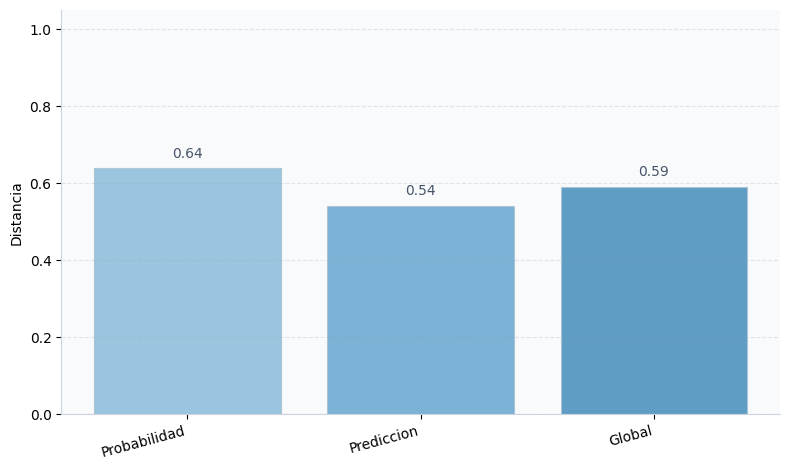

,comprobacion,ok,detalle
0,El drift global supera el umbral minimo,True,drift=0.590
1,Se genera la alerta DATA-01,True,['DATA-01']


In [37]:
# Tomamos la parte anatomica mas frecuente del registro real para concentrar artificialmente las revisiones.
parte_drift = registro_real["parte_anatomica"].mode().iat[0]
candidatos_drift = registro_real[registro_real["parte_anatomica"] == parte_drift].copy()

# Priorizamos casos con probabilidades alejadas de 0.5 para forzar una distribucion mas extrema.
candidatos_drift["distancia_confianza"] = (candidatos_drift["probabilidad_anormalidad"] - 0.5).abs()
registro_escenario_7 = candidatos_drift.sort_values(["etiqueta_predicha", "distancia_confianza"], ascending=[False, False]).head(8).drop(columns="distancia_confianza")

# Aqui no recortamos el registro real del backend. Nos interesa medir la desviacion frente a la referencia completa.
activar_escenario("escenario_07_drift")
registro, _, _, _, _ = core.cargar_estado()

# Guardamos revisiones alineadas con la prediccion para que el foco este en el cambio de distribucion,
# no en empeorar artificialmente el rendimiento clinico.
registrar_revisiones_ids(
    registro,
    registro_escenario_7["id_estudio"].tolist(),
    lambda caso: caso["etiqueta_predicha"],
    "none",
    "Escenario de drift controlado",
)

registro_7, feedback_7, revisados_7, alertas_7, auditoria_7 = core.cargar_estado()
metricas_7 = core.calcular_metricas(revisados_7, registro_real)

# Verificamos dos cosas: que el drift es apreciable y que aparece la alerta dedicada a ese fenomeno.
comprobaciones = []
comprobar(comprobaciones, "El drift global supera el umbral minimo", metricas_7["drift_global"] > 0.15, f"drift={metricas_7['drift_global']:.3f}")
comprobar(comprobaciones, "Se genera la alerta DATA-01", "DATA-01" in set(alertas_7["codigo_alerta"].astype(str)), str(sorted(alertas_7["codigo_alerta"].astype(str).unique().tolist())))

# Resumimos por separado las componentes del drift para que la lectura sea mas clara.
tabla_drift_7 = pd.DataFrame([{
    "casos_revisados": len(revisados_7),
    "drift_parte_anatomica": metricas_7["drift_parte_anatomica"],
    "drift_probabilidad": metricas_7["drift_probabilidad"],
    "drift_prediccion": metricas_7["drift_prediccion"],
    "drift_global": metricas_7["drift_global"],
}])
display(tabla_drift_7)
display(alertas_7[["codigo_alerta", "severidad", "indicador", "valor_observado", "accion_recomendada"]])

# Grafica de apoyo para documentar visualmente el cambio de distribucion.
grafica_drift_7 = pd.Series({
    "Parte anatomica": metricas_7["drift_parte_anatomica"],
    "Probabilidad": metricas_7["drift_probabilidad"],
    "Prediccion": metricas_7["drift_prediccion"],
    "Global": metricas_7["drift_global"],
})
dibujar_barras_suaves(
    grafica_drift_7,
    "Distancia",
    colores=["#b8d6e8", "#95c2dd", "#74aed3", "#5798c2"],
    rotacion=15,
)

mostrar_comprobaciones(comprobaciones)

## 9. Restaurar el estado del backend

Al terminar las pruebas devolvemos el backend a sus rutas originales. Los datos de cada escenario quedan guardados
solo dentro de `code/outputs/pruebas_interfaz` por si se quieren revisar despues.

Esto permite que el notebook sea seguro de ejecutar incluso si la app real ya tiene datos generados,
porque al final todo vuelve a apuntar a los archivos originales.


In [32]:
# Dejamos el backend exactamente como estaba antes de empezar las pruebas.
# Restauramos manualmente las rutas internas del backend para volver
# a los CSV reales de la aplicacion y salir del entorno de pruebas.
core.ARCHIVO_REGISTRO_INFERENCIAS = RUTAS_ORIGINALES["ARCHIVO_REGISTRO_INFERENCIAS"]
core.ARCHIVO_REGISTRO_INFERENCIAS_ANTIGUO = RUTAS_ORIGINALES["ARCHIVO_REGISTRO_INFERENCIAS_ANTIGUO"]
core.ARCHIVO_FEEDBACK = RUTAS_ORIGINALES["ARCHIVO_FEEDBACK"]
core.ARCHIVO_ALERTAS = RUTAS_ORIGINALES["ARCHIVO_ALERTAS"]
core.ARCHIVO_ESTADO_ALERTAS = RUTAS_ORIGINALES["ARCHIVO_ESTADO_ALERTAS"]
core.ARCHIVO_AUDITORIA = RUTAS_ORIGINALES["ARCHIVO_AUDITORIA"]
print("Rutas originales restauradas.")
print("Escenarios guardados en:", RUTA_PRUEBAS)

Rutas originales restauradas.
Escenarios guardados en: /Users/emiliopesenti/Desktop/Practicas&TFG/TFG/SistemaAlerta/code/outputs/pruebas_interfaz
